In [1]:
import hypernetx
import h5py
import hypernetx.drawing
import matplotlib
import matplotlib.figure
import matplotlib.axes
import matplotlib.pyplot as plt
import hypernetx.classes

plt.rcParams['font.sans-serif'] = 'SimSun'
plot_id = 0

In [52]:
import numpy as np

def plot_histogram(graph:hypernetx.classes.Hypergraph, aspect_ratio):
    edge_dist = graph.edge_size_dist()
    unique_elements, counts = np.unique(edge_dist, return_counts=True)
    fig1,_ = plt.subplots()
    fig1.set_size_inches(320 / fig1.dpi,320 / fig1.dpi * aspect_ratio)
    plt.bar(unique_elements, counts)
    plt.xlabel('组规模', size=12)
    plt.ylabel('超边数', size=12)

    node_dist = []
    for i in graph.nodes.items:
        node_dist.append(graph.degree(i))
    unique_elements, counts = np.unique(node_dist, return_counts=True)
    fig2,_ = plt.subplots()
    fig2.set_size_inches(320 / fig2.dpi,320 / fig2.dpi * aspect_ratio)
    plt.bar(unique_elements, counts)
    plt.xlabel('节点度', size=12)
    plt.ylabel('节点数', size=12)

    return fig1, fig2
        


In [2]:
filepath = r"..\tests\data\graphs\node-distrib\4cba3920-3d0c-11f0-2117-d9b5622193ba.hdf5"
plot_id += 1

In [3]:
with h5py.File(filepath, 'r') as f:
    incidence_matrix = f['graph'][:]
    incidence_matrix = incidence_matrix.T
H = hypernetx.Hypergraph.from_incidence_matrix((incidence_matrix))

np.float64(2.6795721933092715)

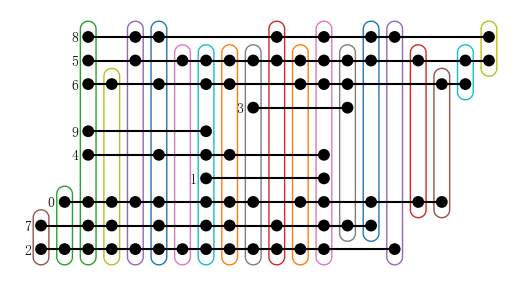

In [5]:

fig: matplotlib.figure.Figure
ax: matplotlib.axes.Axes
fig, ax = matplotlib.pyplot.subplots()
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
# ax.set_position([0, 0, 1, 1])
hypernetx.drawing.draw_incidence_upset(H, ax=ax, edge_labels_on_axis=False, node_labels_on_axis=False, with_node_labels=True, with_edge_labels=False)
# ax.spines[:].set_visible(True)
ax.autoscale_view(tight=True)
aspect_ratio = ax.get_data_ratio()
fig.set_size_inches(5.1, 5.1 * aspect_ratio)
fig.savefig("../results/超图" + str(plot_id) + ".svg", format="svg")
fig.get_figheight()

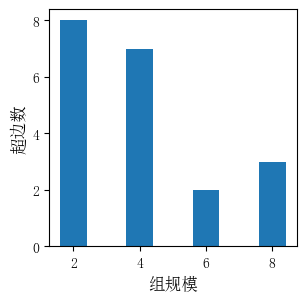

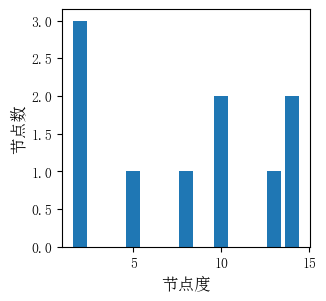

In [56]:
fig_n, fig_e = plot_histogram(H, aspect_ratio)
fig_n.savefig("../results/节点度分布" + str(plot_id) + ".pdf", format="pdf")
fig_e.savefig("../results/组规模分布" + str(plot_id) + ".pdf", format="pdf")

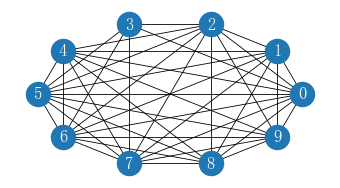

In [73]:
import networkx as nx
nx_graph = H.get_linegraph(edges=False)
fig = plt.gcf()
fig.set_size_inches(320 / fig.dpi,320 / fig.dpi * aspect_ratio)
nx.draw(nx_graph, with_labels=True, font_size=12, font_color='white', width=0.6, pos=nx.layout.circular_layout(nx_graph))
plt.gcf().savefig("../results/置换图" + str(plot_id) + ".pdf", format="pdf")